# Baseline Model Results

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from minou_colours import MINOU_COLOURS
import plotting_config

import matplotlib.pyplot as plt

# This notebook is permanently kept in simulation/notebooks/evaluation.
STUDY_ROOT = Path("../..").resolve()
sys.path.insert(0, str(STUDY_ROOT))
from common.io_utils import StudyPaths
PROJECT_ROOT = STUDY_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

LAMBDA = 10.0
T = 500
RHO_SCALE = 0.03
SEEDS = [42, 43, 44, 45, 46]
MODELS = [
    ('pto', 'mlp', 'PTO MLP', MINOU_COLOURS['teal']),
    ('dfl', 'mlp', 'DFL MLP', MINOU_COLOURS['sage']),
    ('blackbox', 'mlp', 'Black-box MLP', MINOU_COLOURS['navy']),
]
TABLE_MODELS = [
    ('pto', 'linear'), ('pto', 'mlp'),
    ('dfl', 'linear'), ('dfl', 'mlp'),
    ('blackbox', 'linear'), ('blackbox', 'mlp'),
    ('pto', 'persistence'),
]
paths = StudyPaths(study_root=STUDY_ROOT)
RESULTS_DIR = paths.results_dir

FIGURES_DIR = paths.figures_dir / '01_baseline_model_comparison'


In [2]:
def timeseries(family, architecture, seed):
    path = paths.timeseries_csv(family, architecture, seed, LAMBDA, T, RHO_SCALE, 'main')
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path).sort_values('date').reset_index(drop=True)

# Mean regret is the average per-quarter regret in each saved panel.
regret_rows = []
for seed in SEEDS:
    row = {'seed': seed}
    for family, architecture, label, _ in MODELS:
        row[label] = timeseries(family, architecture, seed)['regret'].mean()
    regret_rows.append(row)
regret_by_seed = pd.DataFrame(regret_rows).set_index('seed')
cross_panel_mean = regret_by_seed.mean(axis=0)
selection = regret_by_seed.subtract(cross_panel_mean, axis=1).abs().mean(axis=1)
representative_seed = int(selection.idxmin())

selection_table = regret_by_seed.copy()
selection_table['average absolute distance to model means'] = selection
display(selection_table)
print(f'Representative seed: {representative_seed} (lambda={LAMBDA:g})')
print('Cross-panel means:')
display(cross_panel_mean.to_frame('mean per-quarter regret').T)

,PTO MLP,DFL MLP,Black-box MLP,average absolute distance to model means
seed,,,,
42,0.238973,0.017377,0.019456,0.021772
43,0.219078,0.014770,0.012815,0.014412
44,0.153642,0.020173,0.016401,0.010396
45,0.161036,0.009429,0.010988,0.009679
46,0.124133,0.018338,0.015835,0.019432


Representative seed: 45 (lambda=10)
Cross-panel means:


,PTO MLP,DFL MLP,Black-box MLP
mean per-quarter regret,0.179373,0.016017,0.015099


## Baseline performance table

In [3]:
def baseline_metrics(family, architecture, seed):
    frame = timeseries(family, architecture, seed)
    row = {
        'Model': 'Persistence' if architecture == 'persistence' else (family.replace('blackbox', 'Black-box').upper() if family != 'blackbox' else 'Black-box'),
        'Architecture': '-' if architecture == 'persistence' else architecture.capitalize(),
        'PD MAE': np.nan,
        'c MAE': np.nan,
        'Mean regret': frame['regret'].mean(),
        'Median regret': frame['regret'].median(),
        'Alpha = 0 share': (frame['alpha_hat'].abs() < 1e-10).mean(),
        'seed': seed,
    }
    # Persistence is reported as a c_{t+1} baseline, not as a PD-forecast model.
    if architecture != 'persistence' and 'pd_q_hat' in frame and 'pd_q_true' in frame:
        row['PD MAE'] = (frame['pd_q_hat'] - frame['pd_q_true']).abs().mean()
    if 'c_q_hat' in frame and 'c_q_realised' in frame:
        row['c MAE'] = (frame['c_q_hat'] - frame['c_q_realised']).abs().mean()
    return row

baseline_by_seed = pd.DataFrame(
    baseline_metrics(family, architecture, seed)
    for seed in SEEDS
    for family, architecture in TABLE_MODELS
)
baseline_summary = (
    baseline_by_seed.groupby(['Model', 'Architecture'], sort=False)[
        ['PD MAE', 'c MAE', 'Mean regret', 'Median regret']
    ].mean().reset_index()
)
display(baseline_summary)

latex_rows = []
for model in ['PTO', 'DFL', 'Black-box']:
    sub = baseline_summary[baseline_summary['Model'] == model].set_index('Architecture')
    for i, architecture in enumerate(['Linear', 'Mlp']):
        row = sub.loc[architecture]
        values = [('\\text{--}' if pd.isna(row[c]) else f'{row[c]:.4f}') for c in ['PD MAE', 'c MAE', 'Mean regret', 'Median regret']]
        model_cell = f'\\multirow{{2}}{{*}}{{{model}}}' if i == 0 else ''
        architecture_label = 'MLP' if architecture == 'Mlp' else architecture
        latex_rows.append(f'{model_cell:<27} & {architecture_label} & ' + ' & '.join(values) + ' ' + chr(92) * 2)
    if model != 'Black-box':
        latex_rows.append(r'\midrule')
persistence = baseline_summary[(baseline_summary['Model'] == 'Persistence') & (baseline_summary['Architecture'] == '-')].iloc[0]
persistence_values = [('\\text{--}' if pd.isna(persistence[c]) else f'{persistence[c]:.4f}') for c in ['PD MAE', 'c MAE', 'Mean regret', 'Median regret']]
latex_rows.append(r'\midrule')
latex_rows.append('\\multirow{1}{*}{Persistence} & - & ' + ' & '.join(persistence_values) + ' ' + chr(92) * 2)
latex_summary = '\n'.join([
    r'\begin{table}[H]', r'\centering',
    r'\caption{Baseline simulation performance across DGP and training seeds}',
    r'\label{tab:simulation_baseline}', r'\begin{tabular}{llcccc}', r'\toprule',
    'Model & Architecture & $PD^{Q, \\mathrm{true}}_{t+1}$ MAE & $c_{t+1}$ MAE & Mean regret & Median regret ' + chr(92) * 2,
    r'\midrule', *latex_rows, r'\bottomrule', r'\end{tabular}', r'\end{table}',
])
print(latex_summary)

,Model,Architecture,PD MAE,c MAE,Mean regret,Median regret
0,PTO,Linear,0.001121,0.000580,0.199711,0.029504
1,PTO,Mlp,0.000987,0.000513,0.179373,0.008499
2,DFL,Linear,0.003599,0.001648,0.023723,0.011142
3,DFL,Mlp,0.003508,0.001617,0.016017,0.012489
4,Black-box,Linear,NaN,NaN,0.017918,0.012496
5,Black-box,Mlp,NaN,NaN,0.015099,0.012285
6,Persistence,-,NaN,0.000571,0.249812,0.011546


\begin{table}[H]
\centering
\caption{Baseline simulation performance across DGP and training seeds}
\label{tab:simulation_baseline}
\begin{tabular}{llcccc}
\toprule
Model & Architecture & $PD^{Q, \mathrm{true}}_{t+1}$ MAE & $c_{t+1}$ MAE & Mean regret & Median regret \\
\midrule
\multirow{2}{*}{PTO}        & Linear & 0.0011 & 0.0006 & 0.1997 & 0.0295 \\
                            & MLP & 0.0010 & 0.0005 & 0.1794 & 0.0085 \\
\midrule
\multirow{2}{*}{DFL}        & Linear & 0.0036 & 0.0016 & 0.0237 & 0.0111 \\
                            & MLP & 0.0035 & 0.0016 & 0.0160 & 0.0125 \\
\midrule
\multirow{2}{*}{Black-box}  & Linear & \text{--} & \text{--} & 0.0179 & 0.0125 \\
                            & MLP & \text{--} & \text{--} & 0.0151 & 0.0123 \\
\midrule
\multirow{1}{*}{Persistence} & - & \text{--} & 0.0006 & 0.2498 & 0.0115 \\
\bottomrule
\end{tabular}
\end{table}


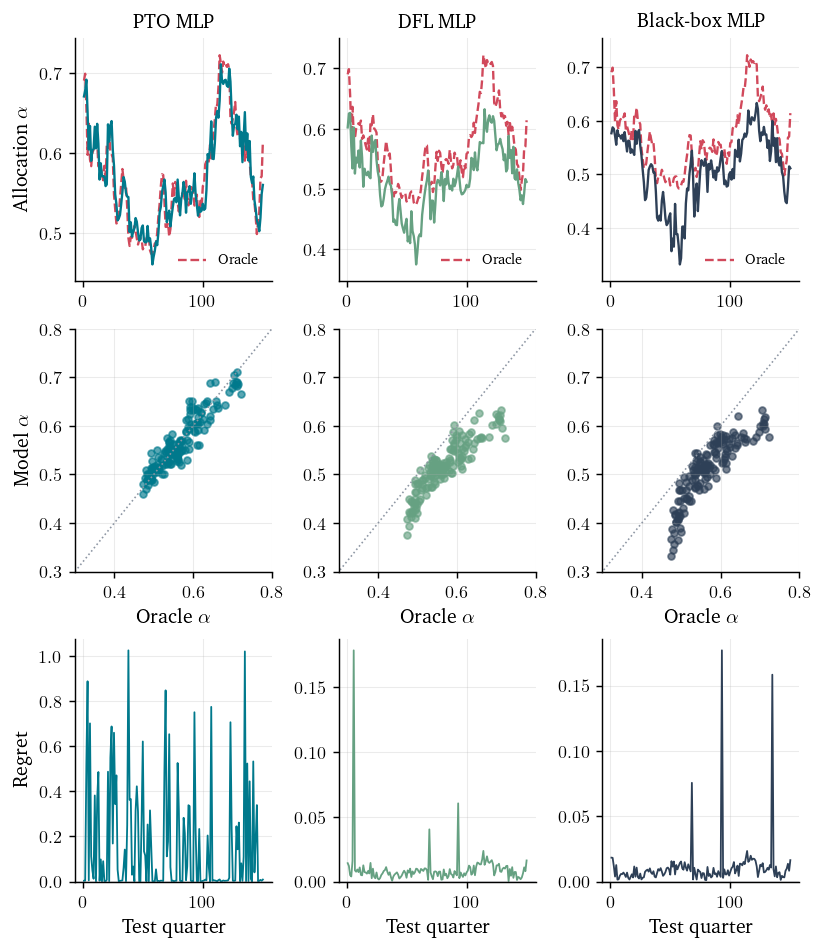

In [4]:
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 300,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
})

def allocation_limits(frame, keys, tolerance=0.08):
    values = np.concatenate([frame[key].to_numpy(dtype=float) for key in keys])
    lo, hi = np.nanmin(values), np.nanmax(values)
    span = hi - lo
    pad = max(0.01, tolerance * span) if span else max(0.01, tolerance * max(abs(lo), 1.0))
    return lo - pad, hi + pad

fig, axes = plt.subplots(3, 3, figsize=(6.22, 7.2), constrained_layout=True)
for col, (family, architecture, label, color) in enumerate(MODELS):
    frame = timeseries(family, architecture, representative_seed)
    t = np.arange(1, len(frame) + 1)
    ax_alloc, ax_scatter, ax_regret = axes[:, col]
    ax_alloc.plot(t, frame['alpha_oracle'], color=MINOU_COLOURS['coral'], lw=1.3, ls='--', label='Oracle')
    ax_alloc.plot(t, frame['alpha_hat'], color=color, lw=1.3)
    ax_alloc.set_title(label)
    ax_alloc.set_ylim(*allocation_limits(frame, ['alpha_oracle', 'alpha_hat']))
    ax_alloc.set_ylabel('Allocation $\\alpha$' if col == 0 else '')
    ax_alloc.legend(frameon=False, fontsize=8, loc='lower right')
    ax_scatter.scatter(frame['alpha_oracle'], frame['alpha_hat'], s=14, color=color, alpha=0.65)
    ax_scatter.plot([0, 1], [0, 1], color=MINOU_COLOURS['grey'], lw=0.9, ls=':')
    ax_scatter.set_xlim(0.3, 0.8); ax_scatter.set_ylim(0.3, 0.8)
    ax_scatter.set_xlabel(r'Oracle $\alpha$')
    ax_scatter.set_ylabel(r'Model $\alpha$' if col == 0 else '')
    ax_regret.plot(t, frame['regret'], color=color, lw=1.0)
    ax_regret.axhline(0, color=MINOU_COLOURS['grey'], lw=0.8)
    ax_regret.set_ylabel('Regret' if col == 0 else '')
    ax_regret.set_xlabel(r'Test quarter')
    ax_regret.set_ylim(bottom=0)
path = FIGURES_DIR / 'representative_seed_allocations_and_regret.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()


## Per-seed diagnostics

In [5]:
# Per-seed tables, split by architecture. Values are computed from each saved timeseries.
diagnostic_cols = ['Mean regret', 'Median regret', 'PD MAE', 'Alpha = 0 share']
for architecture in ['Linear', 'Mlp']:
    table = baseline_by_seed[baseline_by_seed['Architecture'] == architecture].copy()
    table = table.pivot(index='seed', columns='Model', values=diagnostic_cols)
    table = table.swaplevel(0, 1, axis=1).sort_index(axis=1)
    print(f'{architecture} specifications')
    display(table.round(4))


Linear specifications


Model       Black-box                                              DFL  \
      Alpha = 0 share Mean regret Median regret PD MAE Alpha = 0 share   
seed                                                                     
42                0.0      0.0202        0.0130    NaN          0.0000   
43                0.0      0.0129        0.0115    NaN          0.0067   
44                0.0      0.0190        0.0122    NaN          0.0067   
45                0.0      0.0193        0.0090    NaN          0.0200   
46                0.0      0.0182        0.0168    NaN          0.0000   

Model                                               PTO              \
      Mean regret Median regret  PD MAE Alpha = 0 share Mean regret   
seed                                                                  
42         0.0269        0.0128  0.0037             0.0      0.2563   
43         0.0222        0.0112  0.0037             0.0      0.2072   
44         0.0380        0.0106  0.0029             0.0      0.1706   
45         0.0149        0.0084  0.0050             0.0      0.2524   
46         0.0166        0.0126  0.0027             0.0      0.1121   

Model                        
      Median regret  PD MAE  
seed                         
42           0.0122  0.0012  
43           0.0102  0.0014  
44           0.0075  0.0010  
45           0.1105  0.0013  
46           0.0071  0.0008

Mlp specifications


Model       Black-box                                              DFL  \
      Alpha = 0 share Mean regret Median regret PD MAE Alpha = 0 share   
seed                                                                     
42                0.0      0.0195        0.0160    NaN          0.0000   
43                0.0      0.0128        0.0110    NaN          0.0067   
44                0.0      0.0164        0.0126    NaN          0.0000   
45                0.0      0.0110        0.0082    NaN          0.0000   
46                0.0      0.0158        0.0136    NaN          0.0000   

Model                                               PTO              \
      Mean regret Median regret  PD MAE Alpha = 0 share Mean regret   
seed                                                                  
42         0.0174        0.0144  0.0038             0.0      0.2390   
43         0.0148        0.0113  0.0043             0.0      0.2191   
44         0.0202        0.0142  0.0031             0.0      0.1536   
45         0.0094        0.0073  0.0034             0.0      0.1610   
46         0.0183        0.0152  0.0030             0.0      0.1241   

Model                        
      Median regret  PD MAE  
seed                         
42           0.0108  0.0011  
43           0.0101  0.0012  
44           0.0065  0.0009  
45           0.0085  0.0010  
46           0.0066  0.0007